In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.utils.utils import load_file

import torch
from torch import nn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Restaurant data with the 25 most frequent ingredients
restaurant_data_df = load_file('../../data/kaggle/Restaurant_frequent_ings.csv')

# Filter restaurant data by salt
restaurant_salt_data_df = restaurant_data_df[restaurant_data_df['Ingredient'] == 'salt'].copy()
#display(restaurant_salt_data_df)

# Obtain daily salt consumption
restaurant_salt_data_df['DateTime'] = pd.to_datetime(restaurant_salt_data_df['DateTime']) # Convert DateTime column to datetime type
restaurant_salt_data_df['Date'] = restaurant_salt_data_df['DateTime'].dt.date # Extract date from DateTime
daily_salt_consumption = restaurant_salt_data_df.groupby(['Date', 'DayType'])['Total Quantity'].sum().reset_index() # group by Day
daily_salt_consumption = daily_salt_consumption.rename(columns={'Total Quantity': 'Quantity'}) # Rename 'Total Quantity' to 'Quantity'
display(daily_salt_consumption)

,Date,DayType,Quantity
0,2019-01-01,Weekday,153.557043
1,2019-01-02,Weekend,101.122931
2,2019-01-03,Weekday,119.849399
3,2019-01-04,Weekday,97.377637
4,2019-01-05,Weekend,202.245861
...,...,...,...
176,2019-06-26,Weekend,116.104106
177,2019-06-27,Weekday,205.991155
178,2019-06-28,Weekday,179.774099
179,2019-06-29,Weekend,159.174983


In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

daily_salt_consumption_coded = daily_salt_consumption.copy()

# Assuming df is your DataFrame
daily_salt_consumption_coded['DayType'] = LabelEncoder().fit_transform(daily_salt_consumption_coded['DayType'])

# Normalize the quantity
scaler = StandardScaler()
daily_salt_consumption_coded['Quantity'] = scaler.fit_transform(daily_salt_consumption_coded[['Quantity']])

In [4]:
daily_salt_consumption_coded

,Date,DayType,Quantity
0,2019-01-01,0,-0.401511
1,2019-01-02,1,-0.829631
2,2019-01-03,0,-0.676731
3,2019-01-04,0,-0.860211
4,2019-01-05,1,-0.003970
...,...,...,...
176,2019-06-26,1,-0.707311
177,2019-06-27,0,0.026610
178,2019-06-28,0,-0.187451
179,2019-06-29,1,-0.355641


In [15]:
from copy import deepcopy as dc

def generate_time_sequences(df, lookback):
    # Deep copy the dataframe to avoid modifying the original data
    df = dc(df)   

    # Set the Date column as the index
    df.set_index('Date', inplace=True)
    #display(df.head(11))

    # Create time-shifted features
    for i in range(1, lookback + 1):
        df[f'DayT(t-{i})'] = df['DayType'].shift(i)
        df[f'Qty(t-{i})'] = df['Quantity'].shift(i)
       
    # Drop rows with NaN values generated by the shift
    df.dropna(inplace=True)

    return df

print()

lookback = 2
shifted_df = generate_time_sequences(daily_salt_consumption_coded, lookback)
shifted_df = shifted_df.iloc[:, 1:] # Remove DayType column
display(shifted_df)

# Convert the DataFrame to a numpy array
shifted_df_as_np = shifted_df.to_numpy() 
print(f"Shape numpy: {shifted_df_as_np.shape}, Dimensions: {shifted_df_as_np.ndim}")
#display(shifted_df_as_np)

# Split into inputs (X) and target (y)
X = shifted_df_as_np[:, 1:]
y = shifted_df_as_np[:, 0]  
print(f"X - Shape numpy: {X.shape}, Dimensions: {X.ndim}")
print(f"y - Shape numpy: {y.shape}, Dimensions: {y.ndim}", '\n')

# Reverse the order of the input sequences
X = dc(np.flip(X, axis=1))

# Reshape the data for LSTM input
# Is a requirement for pytorch lstm to have an extra dimension at the end
X, y = X.reshape((-1, lookback, 2)), y.reshape((-1, 1))
print(f"X - ReShape numpy: {X.shape}, Dimensions: {X.ndim}")
print(f"y - ReShape numpy: {y.shape}, Dimensions: {y.ndim}", '\n')

# Determine the split index for training and testing data
train_size = int(len(X) * 0.95)

# Split the data into training and testing sets
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert the numpy arrays to PyTorch tensors
X_train, X_test = torch.tensor(X_train).float(), torch.tensor(X_test).float()
y_train, y_test = torch.tensor(y_train).float(), torch.tensor(y_test).float()
print(f"X train - tensor: {X_train.shape}, Dimensions: {X_train.ndim}")
print(f"y  train- tensor: {y_train.shape}, Dimensions: {y_train.ndim}", '\n')


,Quantity,DayT(t-1),Qty(t-1),DayT(t-2),Qty(t-2)
Date,,,,,
2019-01-03,-0.676731,1.0,-0.829631,0.0,-0.401511
2019-01-04,-0.860211,0.0,-0.676731,1.0,-0.829631
2019-01-05,-0.003970,0.0,-0.860211,0.0,-0.676731
2019-01-06,0.470020,1.0,-0.003970,0.0,-0.860211
2019-01-07,1.907282,1.0,0.470020,1.0,-0.003970
...,...,...,...,...,...
2019-06-26,-0.707311,0.0,0.378280,0.0,2.075472
2019-06-27,0.026610,1.0,-0.707311,0.0,0.378280
2019-06-28,-0.187451,0.0,0.026610,1.0,-0.707311


Shape numpy: (179, 5), Dimensions: 2
X - Shape numpy: (179, 4), Dimensions: 2
y - Shape numpy: (179,), Dimensions: 1 

X - ReShape numpy: (179, 2, 2), Dimensions: 3
y - ReShape numpy: (179, 1), Dimensions: 2 

X train - tensor: torch.Size([170, 2, 2]), Dimensions: 3
y  train- tensor: torch.Size([170, 1]), Dimensions: 2 



In [25]:
X

array([[[-0.4015108 ,  0.        ],
        [-0.8296313 ,  1.        ]],

       [[-0.8296313 ,  1.        ],
        [-0.67673112,  0.        ]],

       [[-0.67673112,  0.        ],
        [-0.86021134,  0.        ]],

       [[-0.86021134,  0.        ],
        [-0.00397034,  1.        ]],

       [[-0.00397034,  1.        ],
        [ 0.47002022,  1.        ]],

       [[ 0.47002022,  1.        ],
        [ 1.9072819 ,  0.        ]],

       [[ 1.9072819 ,  0.        ],
        [ 0.01131968,  0.        ]],

       [[ 0.01131968,  0.        ],
        [-1.22717177,  1.        ]],

       [[-1.22717177,  1.        ],
        [-0.61557105,  0.        ]],

       [[-0.61557105,  0.        ],
        [-1.36478193,  0.        ]],

       [[-1.36478193,  0.        ],
        [ 1.21923109,  1.        ]],

       [[ 1.21923109,  1.        ],
        [ 2.12134215,  1.        ]],

       [[ 2.12134215,  1.        ],
        [ 1.55561149,  0.        ]],

       [[ 1.55561149,  0.        ],
  

In [17]:
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Iterate over the train_dataloader
# for _, batch in enumerate(train_dataloader):
#     x_batch, y_batch = batch[0].to(device), batch[1].to(device)
#     print(x_batch.shape, y_batch.shape)
#     print(batch)
#     break

In [19]:
class LSTM(nn.Module):
    '''
    input_size - The number of expected features in the input x
    hidden_size - The number of features in the hidden state h
    num_layers - Number of recurrent layers
    '''
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) 

        # Fully connected linear layer
        self.fc = nn.Linear(hidden_size, output_size)   

    def forward(self, x):
        batch_size = x.size(0)

        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        # Initialize cell state
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) # Linear layer will map the LSTM output to the desired output size (1, in this case)
        return out
    

features_number = 2 # Quantity and DayType
hidden_size = 50
num_stack_layers = 2
output_size = 1

print("Creating LSTM model ...")
model = LSTM(features_number, hidden_size, num_stack_layers, output_size)
print(model)

Creating LSTM model ...
LSTM(
  (lstm): LSTM(2, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [20]:
import torch.optim as optim


def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()   # Set the model to training mode
    
    num_batches = len(dataloader)   # Number of total batches
    train_loss = 0.0

    #for batch_index, batch in enumerate(dataloader):
    for X_batch, y_batch in dataloader:
        #batch_size = len(batch)
        #X_batch, y_batch = batch[0], batch[1]

        # Compute prediction and loss
        prediction = model(X_batch)
        loss = loss_fn(prediction, y_batch)

        # Backpropagation
        optimizer.zero_grad()   # Reset the gradients of model parameters
        loss.backward() # Determine the gradients for this loop
        optimizer.step()    # Adjust the parameters by the gradients collected in the backward pass.

        train_loss += loss.item()   # sum all the train losses
        # if batch_index % 10 == 0:
        #     loss, current = loss.item(), batch_index * batch_size + len(X_batch)
        #     print(f"Batch {batch_index} - loss: {loss:>7f}  [{current:>3d}/{size:>3d}]")
    
    train_loss /= num_batches  # average loss of each epoch
    return train_loss

def test_loop(dataloader, model, loss_fn):
    model.eval()    # Set the model to evaluation mode

    #size = len(dataloader.dataset)  # Number of samples
    num_batches = len(dataloader)   # Number of total batches 
    test_loss = 0.0
    total_absolute_error = 0.0 
    total_squared_error = 0.0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            prediction = model(X_batch)
            loss = loss_fn(prediction, y_batch)

            test_loss += loss.item()    # sum all the test losses
            total_absolute_error += torch.abs(prediction - y_batch).sum().item()
            total_squared_error += torch.square(prediction - y_batch).sum().item()

    test_loss /= num_batches
    #mean_absolute_error = total_absolute_error / size
    # mean_squared_error = total_squared_error / size
    # root_mean_squared_error = mean_squared_error ** 0.5

    # print(f"Test Error: \n Avg loss: {test_loss:>3f}, 
    #       MAE: {mean_absolute_error:>3f}, 
    #       MSE: {mean_squared_error:>3f}, 
    #       RMSE: {root_mean_squared_error:>3f} \n")
    return test_loss

learning_rate = 0.001
num_epochs = 20

loss_function = nn.MSELoss()    # loss function - Mean Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

print("\n", "------------ LSTM Model Training & Evaluations Results ------------", "\n")
for epoch in range(num_epochs):
    train_loss = train_loop(train_dataloader, model, loss_function, optimizer)
    val_loss = test_loop(test_dataloader, model, loss_function)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss}, Val Loss: {val_loss}')
print("\nDone!")


 ------------ LSTM Model Training & Evaluations Results ------------ 

Epoch 1/20, Train Loss: 1.0195872883001964, Val Loss: 0.7738783359527588
Epoch 2/20, Train Loss: 1.0137156347433727, Val Loss: 0.777313768863678
Epoch 3/20, Train Loss: 1.0737249652544658, Val Loss: 0.7715483903884888
Epoch 4/20, Train Loss: 1.0490356584390004, Val Loss: 0.7652743458747864
Epoch 5/20, Train Loss: 0.9940892358620962, Val Loss: 0.7586815357208252
Epoch 6/20, Train Loss: 0.9436596830685934, Val Loss: 0.7479676604270935
Epoch 7/20, Train Loss: 0.9269118309020996, Val Loss: 0.7349354028701782
Epoch 8/20, Train Loss: 0.9367215236028036, Val Loss: 0.7182890176773071
Epoch 9/20, Train Loss: 0.960891584555308, Val Loss: 0.695357620716095
Epoch 10/20, Train Loss: 0.8731223940849304, Val Loss: 0.6472679972648621
Epoch 11/20, Train Loss: 0.8378772636254629, Val Loss: 0.5993319153785706
Epoch 12/20, Train Loss: 0.7876653075218201, Val Loss: 0.5306786894798279
Epoch 13/20, Train Loss: 0.7994159956773123, Val Los

In [21]:
# with torch.no_grad():
#     predicted = model(X_train).to('cpu').numpy()

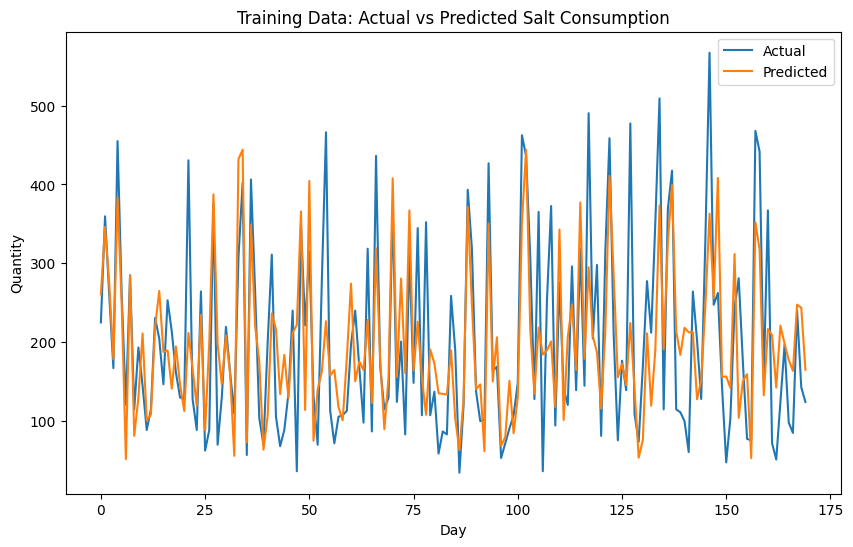

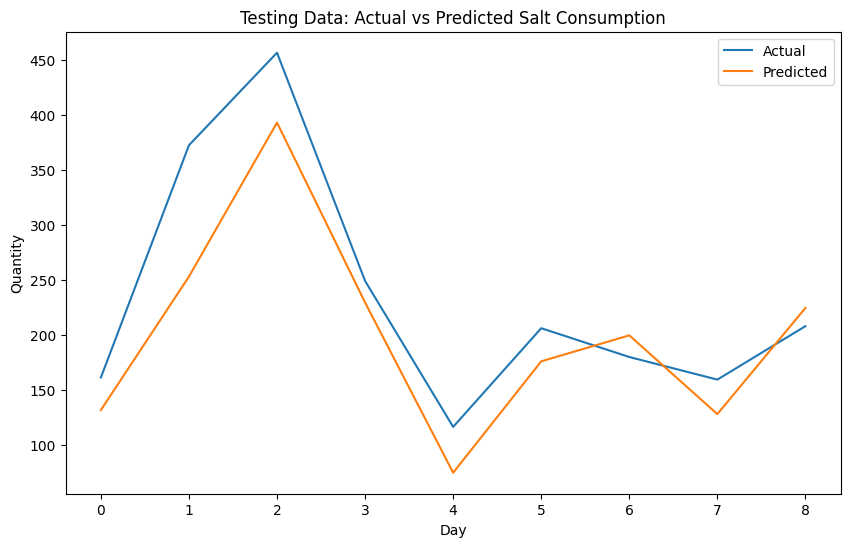

In [22]:
def get_predictions(loader):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    return predictions, actuals

def plot_predictions(predictions, actuals, title):
    plt.figure(figsize=(10, 6))
    plt.plot(actuals, label='Actual')
    plt.plot(predictions, label='Predicted')
    plt.title(title)
    plt.xlabel('Day')
    plt.ylabel('Quantity')
    plt.legend()
    plt.show()

train_predictions, train_actuals = get_predictions(train_dataloader)
test_predictions, test_actuals = get_predictions(test_dataloader)
# plot_predictions(train_predictions, train_actuals, 'Training Data: Actual vs Predicted')
# plot_predictions(test_predictions, test_actuals, 'Testing Data: Actual vs Predicted')

# Denormalize the data
train_predictions_denorm = scaler.inverse_transform(train_predictions)
train_actuals_denorm = scaler.inverse_transform(train_actuals)
test_predictions_denorm = scaler.inverse_transform(test_predictions)
test_actuals_denorm = scaler.inverse_transform(test_actuals)

plot_predictions(train_predictions_denorm, train_actuals_denorm,'Training Data: Actual vs Predicted Salt Consumption')
plot_predictions(test_predictions_denorm, test_actuals_denorm, 'Testing Data: Actual vs Predicted Salt Consumption')

In [23]:
# Ensure the arrays are 1-dimensional
test_actuals_denorm = test_actuals_denorm.flatten()
test_predictions_denorm = test_predictions_denorm.flatten()

# Create a DataFrame
data = {
    'Real Quantities': test_actuals_denorm,
    'Predicted Quantities': test_predictions_denorm
}
df = pd.DataFrame(data)

# Display the DataFrame as a table
print("Testing data - Real and Predicted Quantities:")
display(df)

Testing data - Real and Predicted Quantities:


,Real Quantities,Predicted Quantities
0,161.047632,131.424973
1,372.656721,253.011514
2,456.925838,393.266369
3,249.062032,229.403029
4,116.104106,74.365614
5,205.991155,175.819201
6,179.774098,199.492463
7,159.174984,127.757081
8,207.863802,224.446774
